In [96]:
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from statsmodels.regression.rolling import RollingOLS

# --- 1. SETUP PARAMETERS ---
tickers = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META']
start_date = '2015-01-01'
end_date = '2024-12-31'
csv_file_name = 'F-F_Research_Data_Factors.CSV' # Make sure this matches your file name exactly!

In [98]:
# --- 2. DOWNLOAD STOCK DATA (Safe Mode) ---
print("Downloading stock data...")

# 1. Download all data first (without selecting columns yet)
# We add 'auto_adjust=False' to FORCE it to give us 'Adj Close'
raw_data = yf.download(tickers, start=start_date, end=end_date, interval='1mo', auto_adjust=False)

# 2. Check if the download actually worked
if raw_data.empty:
    print("❌ ERROR: The download failed. No data received.")
    print("Check your internet connection or the ticker names.")
else:
    print("✅ Data downloaded successfully!")
    
    # 3. Try to select 'Adj Close', but have a backup plan
    # Sometimes Yahoo gives 'Adj Close', sometimes just 'Close'
    if 'Adj Close' in raw_data.columns:
        stock_data = raw_data['Adj Close']
        print("Using column: 'Adj Close'")
    elif 'Close' in raw_data.columns:
        stock_data = raw_data['Close']
        print("Note: 'Adj Close' not found. Using 'Close' instead (this is fine).")
    else:
        # If using an older version, the levels might be swapped
        print("⚠️ Unexpected column structure. Printing first 5 rows:")
        print(raw_data.head())
        # Emergency fallback: Just take the first level if it looks like multi-index
        stock_data = raw_data.xs('Adj Close', level=0, axis=1) 

    # 4. Calculate returns
    stock_returns = stock_data.pct_change().dropna()

    # 5. formatting stock dates to match Fama-French format (Monthly Period)
    stock_returns.index = stock_returns.index.to_period('M')
    
    print("Stock returns calculated successfully.")

[*********************100%***********************]  5 of 5 completed

✅ Data downloaded successfully!
Using column: 'Adj Close'
Stock returns calculated successfully.


In [100]:
raw_data.head()

Price       Adj Close                                                 Close  \
Ticker           AAPL      GOOGL       META       MSFT      NVDA       AAPL   
Date                                                                          
2015-01-01  25.973392  26.693394  75.444908  34.501617  0.460722  29.290001   
2015-02-01  28.478514  27.938805  78.486153  37.447910  0.529351  32.115002   
2015-03-01  27.693970  27.545023  81.716240  34.970776  0.504169  31.107500   
2015-04-01  27.854214  27.250551  78.287392  41.834198  0.534761  31.287500   
2015-05-01  28.995985  27.079233  78.704811  40.303257  0.533075  32.570000   

Price                                                 ...       Open  \
Ticker          GOOGL       META       MSFT     NVDA  ...       AAPL   
Date                                                  ...              
2015-01-01  26.877501  75.910004  40.400002  0.48000  ...  27.847500   
2015-02-01  28.131500  78.970001  43.849998  0.55150  ...  29.512501   
2015-03-01  27.735001  82.220001  40.660000  0.52325  ...  32.312500   
2015-04-01  27.438499  78.769997  48.639999  0.55500  ...  31.205000   
2015-05-01  27.266001  79.190002  46.860001  0.55325  ...  31.525000   

Price                                                     Volume              \
Ticker          GOOGL       META       MSFT     NVDA        AAPL       GOOGL   
Date                                                                           
2015-01-01  26.629999  78.580002  46.660000  0.50325  5221053600  1056926000   
2015-02-01  26.716000  76.110001  40.590000  0.48300  4546140800   808386000   
2015-03-01  28.350000  79.000000  43.669998  0.55000  4554568400   864144000   
2015-04-01  27.741501  82.500000  40.599998  0.52525  3984542000   874900000   
2015-05-01  27.525499  79.239998  48.580002  0.55950  3816608400   648434000   

Price                                         
Ticker           META       MSFT        NVDA  
Date                                          
2015-01-01  546210700  918966800  4140352000  
2015-02-01  475148700  656509700  4193540000  
2015-03-01  575349900  824335300  7310444000  
2015-04-01  542124600  874535300  5673652000  
2015-05-01  421870700  633072800  7081336000  

[5 rows x 30 columns]

In [102]:
# --- 3. LOAD FAMA-FRENCH DATA (Stricter Fix) ---
print("Reading Fama-French file...")

try:
    # Skip the first 3 rows of text
    ff_data = pd.read_csv(csv_file_name, skiprows=3)

    # 1. Rename and drop empty rows
    ff_data = ff_data.rename(columns={'Unnamed: 0': 'Date'})
    ff_data = ff_data.dropna()

    # 2. STRICT FILTERING
    # Convert to string and remove any accidental spaces
    ff_data['Date'] = ff_data['Date'].astype(str).str.strip()

    # Keep ONLY rows that are exactly 6 digits (e.g., "202001")
    # This removes the "1927" annual rows and any copyright text at the bottom
    ff_data = ff_data[ff_data['Date'].str.len() == 6]

    # 3. Convert to Datetime
    ff_data['Date'] = pd.to_datetime(ff_data['Date'], format='%Y%m')
    ff_data = ff_data.set_index('Date').to_period('M')

    # 4. Convert data to numbers
    ff_data = ff_data.astype(float) / 100
    ff_data = ff_data.rename(columns={'Mkt-RF': 'Mkt_RF'})
    
    print("✅ Fama-French data loaded successfully!")

except Exception as e:
    print(f"❌ ERROR: {e}")

Reading Fama-French file...
✅ Fama-French data loaded successfully!


In [124]:
# --- SUMMARY STATISTICS TABLE ---

# 1. Create a combined dataframe of just the columns we care about
# We want the Raw Stock Returns and the Factors
summary_data = merged_data[tickers].copy()
summary_data['Mkt_RF'] = merged_data['Mkt_RF']
summary_data['SMB'] = merged_data['SMB']
summary_data['HML'] = merged_data['HML']

# 2. Calculate the stats
summary_table = summary_data.describe().T # Transpose so stocks are rows

# 3. Add Annualized Mean and Volatility (Optional but professional)
# Monthly Mean * 12, Monthly Std * sqrt(12)
summary_table['Ann. Mean'] = summary_table['mean'] * 12
summary_table['Ann. Vol'] = summary_table['std'] * (12**0.5)

# 4. Select and Rename columns for the paper
final_table = summary_table[['count', 'mean', 'std', 'min', 'max', 'Ann. Mean', 'Ann. Vol']]
final_table.columns = ['Obs', 'Monthly Mean', 'Monthly Std', 'Min', 'Max', 'Ann. Mean', 'Ann. Vol']

# 5. Display
print("--- Table 1: Summary Statistics (2015-2024) ---")
print(final_table.round(4)) # Round to 4 decimal places

--- Table 1: Summary Statistics (2015-2024) ---
          Obs  Monthly Mean  Monthly Std     Min     Max  Ann. Mean  Ann. Vol
AAPL    119.0        0.0223       0.0797 -0.1840  0.2144     0.2676    0.2761
MSFT    119.0        0.0230       0.0617 -0.1074  0.1963     0.2765    0.2136
GOOGL   119.0        0.0189       0.0692 -0.1795  0.2175     0.2268    0.2397
NVDA    119.0        0.0576       0.1348 -0.3202  0.3840     0.6916    0.4670
META    119.0        0.0221       0.0976 -0.3263  0.2716     0.2658    0.3381
Mkt_RF  119.0        0.0102       0.0459 -0.1337  0.1360     0.1218    0.1591
SMB     119.0       -0.0013       0.0280 -0.0593  0.0714    -0.0152    0.0970
HML     119.0       -0.0016       0.0379 -0.1383  0.1286    -0.0188    0.1313


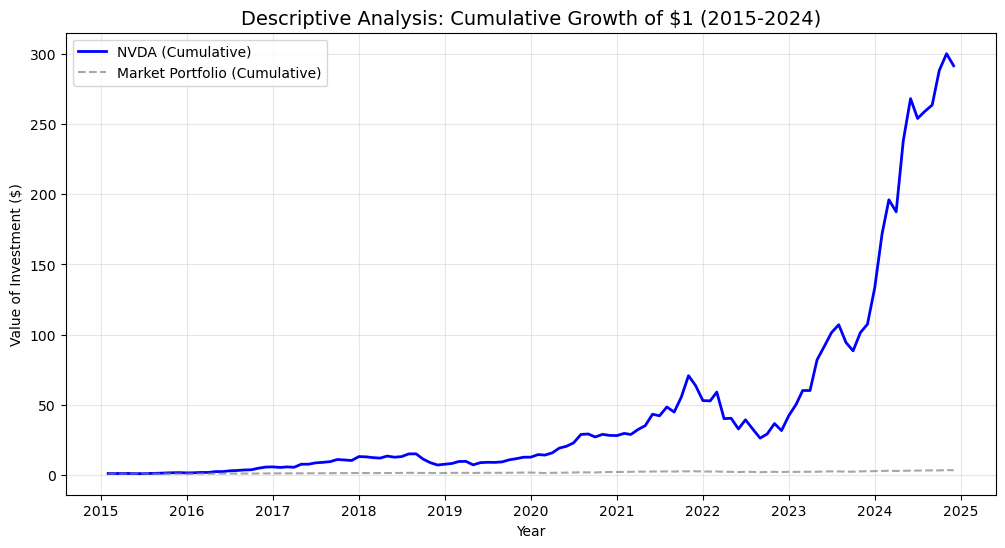

In [104]:
# --- VISUALIZATION: CUMULATIVE RETURNS (The "Trend" Graph) ---

# 1. Calculate Cumulative Returns (Growth of $1) for the FULL period
# We use (1 + Return).cumprod()
stock_cumulative = (1 + merged_data[stock_name]).cumprod()
market_cumulative = (1 + merged_data['Mkt_RF'] + merged_data['RF']).cumprod() # Mkt_RF is excess, so add RF back for total return

# 2. Plot
plt.figure(figsize=(12, 6))

plt.plot(stock_cumulative.index.to_timestamp(), 
         stock_cumulative, 
         label=f'{stock_name} (Cumulative)', color='blue', linewidth=2)

plt.plot(market_cumulative.index.to_timestamp(), 
         market_cumulative, 
         label='Market Portfolio (Cumulative)', color='gray', linestyle='--', alpha=0.7)

plt.title(f'Descriptive Analysis: Cumulative Growth of $1 (2015-2024)', fontsize=14)
plt.ylabel('Value of Investment ($)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

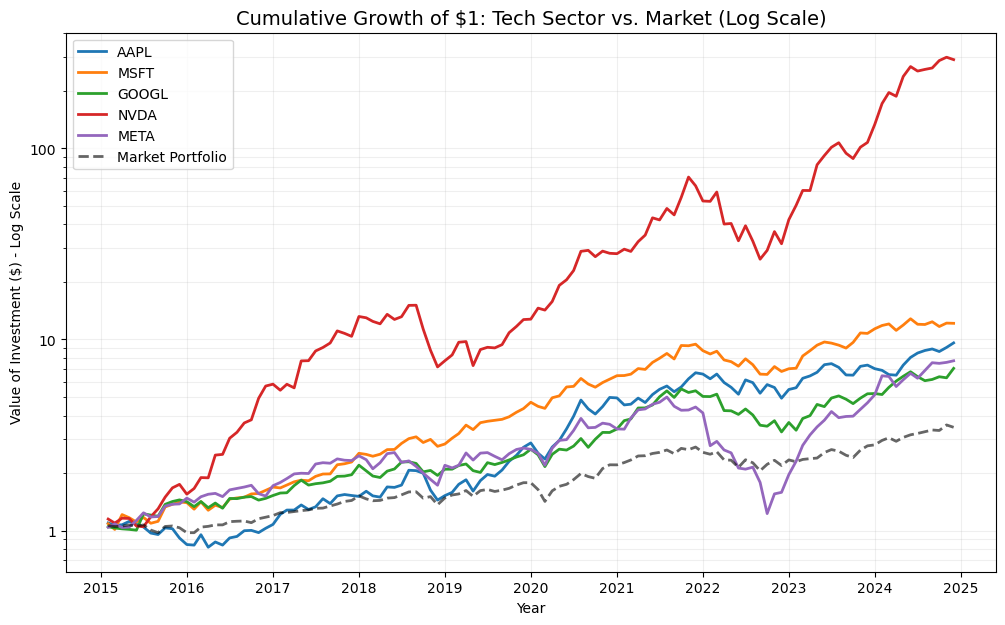

In [106]:
# --- VISUALIZATION 3: ALL STOCKS (Log Scale) ---
# The reason I did log scale is to show all the tech stocks we observe without them being completely squashed by NVDA's huge increase

plt.figure(figsize=(12, 7))

# 1. Loop through all your tickers to plot them
for ticker in tickers:
    # FIX IS HERE: Use 'ticker' instead of f'{ticker}_ret'
    # We calculate the cumulative return for each stock column directly
    cumulative = (1 + merged_data[ticker]).cumprod()
    
    # Plot with a label
    plt.plot(cumulative.index.to_timestamp(), 
             cumulative, 
             label=ticker, linewidth=2)

# 2. Plot the Market for comparison
# Note: Mkt-RF is excess return, so we add RF back to get total market return
market_cumulative = (1 + merged_data['Mkt_RF'] + merged_data['RF']).cumprod()

plt.plot(market_cumulative.index.to_timestamp(), 
         market_cumulative, 
         label='Market Portfolio', color='black', linestyle='--', linewidth=2, alpha=0.6)

# 3. SET LOG SCALE (The Magic Step)
plt.yscale('log')

# 4. Add formatting
plt.title('Cumulative Growth of $1: Tech Sector vs. Market (Log Scale)', fontsize=14)
plt.ylabel('Value of Investment ($) - Log Scale')
plt.xlabel('Year')

# Customize the Y-axis ticks so they look like normal numbers ($10, $100) instead of 10^1, 10^2
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2) # Grid for both major and minor ticks
plt.show()

In [108]:
# --- 4. MERGE DATA & RUN REGRESSIONS ---

# Only proceed if both parts worked
if not raw_data.empty and 'ff_data' in locals():
    
    merged_data = stock_returns.join(ff_data, how='inner')

    for ticker in tickers:
        print(f"\n{'='*40}")
        print(f"ANALYSIS FOR: {ticker}")
        print(f"{'='*40}")
        
        # Define Y (Excess Return)
        y_col = f'{ticker}_ex_ret'
        merged_data[y_col] = merged_data[ticker] - merged_data['RF']
        Y = merged_data[y_col]
        
        # --- MODEL 1: CAPM ---
        X_capm = sm.add_constant(merged_data['Mkt_RF'])
        capm_model = sm.OLS(Y, X_capm).fit()
        
        # --- MODEL 2: FAMA-FRENCH 3-FACTOR ---
        X_ff3f = sm.add_constant(merged_data[['Mkt_RF', 'SMB', 'HML']])
        ff3f_model = sm.OLS(Y, X_ff3f).fit()
        
        # --- PRINT RESULTS FOR YOUR PAPER ---
        print("\n--- Model 1: CAPM Results ---")
        print(f"Adj. R-squared: {capm_model.rsquared_adj:.4f}")
        print(f"Alpha:          {capm_model.params['const']:.4f} (p={capm_model.pvalues['const']:.3f})")
        print(f"Market Beta:    {capm_model.params['Mkt_RF']:.4f}")
        
        print("\n--- Model 2: Fama-French Results ---")
        print(f"Adj. R-squared: {ff3f_model.rsquared_adj:.4f}")
        print(f"Alpha:          {ff3f_model.params['const']:.4f} (p={ff3f_model.pvalues['const']:.3f})")
        print(f"SMB Beta (Size):{ff3f_model.params['SMB']:.4f} (p={ff3f_model.pvalues['SMB']:.3f})")
        print(f"HML Beta (Val): {ff3f_model.params['HML']:.4f} (p={ff3f_model.pvalues['HML']:.3f})")
        print("-" * 40)

    print("\n🎉 Analysis Complete! Copy these numbers into your Word table.")


ANALYSIS FOR: AAPL

--- Model 1: CAPM Results ---
Adj. R-squared: 0.4549
Alpha:          0.0089 (p=0.108)
Market Beta:    1.1766

--- Model 2: Fama-French Results ---
Adj. R-squared: 0.5154
Alpha:          0.0075 (p=0.156)
SMB Beta (Size):-0.1652 (p=0.392)
HML Beta (Val): -0.5247 (p=0.000)
----------------------------------------

ANALYSIS FOR: MSFT

--- Model 1: CAPM Results ---
Adj. R-squared: 0.4407
Alpha:          0.0125 (p=0.005)
Market Beta:    0.8968

--- Model 2: Fama-French Results ---
Adj. R-squared: 0.6062
Alpha:          0.0097 (p=0.009)
SMB Beta (Size):-0.6639 (p=0.000)
HML Beta (Val): -0.4349 (p=0.000)
----------------------------------------

ANALYSIS FOR: GOOGL

--- Model 1: CAPM Results ---
Adj. R-squared: 0.3862
Alpha:          0.0079 (p=0.122)
Market Beta:    0.9425

--- Model 2: Fama-French Results ---
Adj. R-squared: 0.4464
Alpha:          0.0059 (p=0.226)
SMB Beta (Size):-0.4629 (p=0.011)
HML Beta (Val): -0.3178 (p=0.013)
----------------------------------------


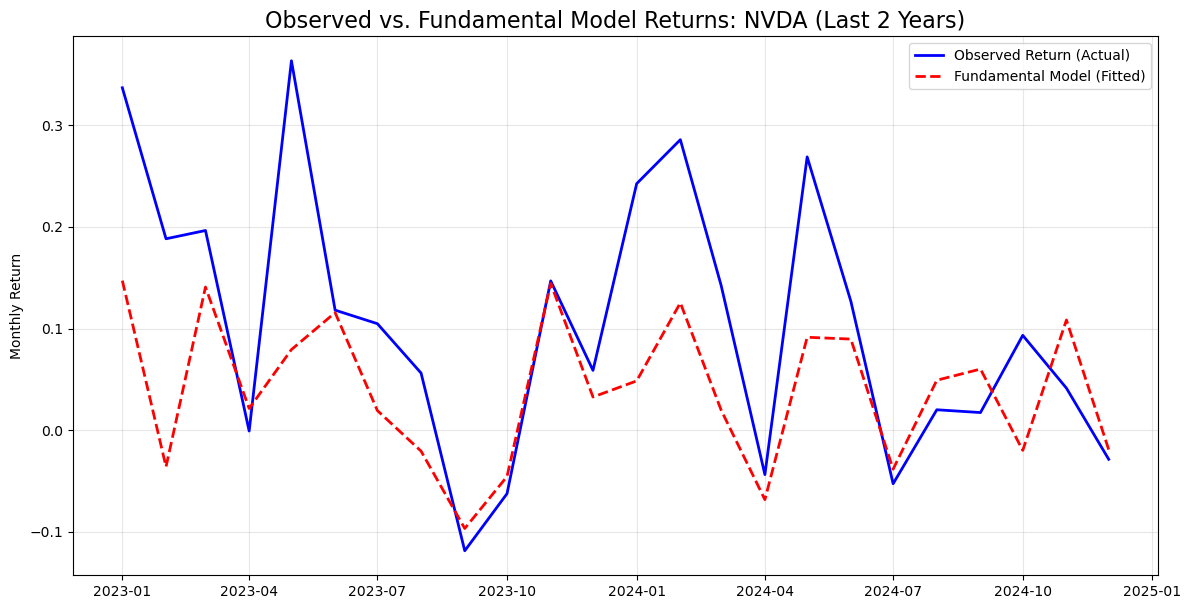

In [111]:
# --- VISUALIZATION: ACTUAL vs FITTED  ---

# 1. Pick your best example stock
stock_name = 'NVDA' 

# 2. Calculate the "Fitted" (Predicted) Return
# First, we need to get the specific betas for NVDA again
y_col = f'{stock_name}_ex_ret'
X_ff3f = sm.add_constant(merged_data[['Mkt_RF', 'SMB', 'HML']])
final_model = sm.OLS(merged_data[y_col], X_ff3f).fit()

# Extract the coefficients (betas)
b_alpha = final_model.params['const']
b_mkt = final_model.params['Mkt_RF']
b_smb = final_model.params['SMB']
b_hml = final_model.params['HML']

# Calculate Fitted Values based on the Fama-French formula
# Fitted = RF + (Beta_Mkt * Mkt) + (Beta_SMB * SMB) + (Beta_HML * HML)
fitted_return = (merged_data['RF'] + 
                 (b_mkt * merged_data['Mkt_RF']) + 
                 (b_smb * merged_data['SMB']) + 
                 (b_hml * merged_data['HML']))

# 3. Plot Actual vs Fundamental
plt.figure(figsize=(14, 7))

# Plotting the last 24 months for clarity
subset = -24 

# --- THE FIX IS HERE: We use 'stock_name' instead of f'{stock_name}_ret' ---
plt.plot(merged_data.index.to_timestamp()[subset:], 
         merged_data[stock_name][subset:], 
         label='Observed Return (Actual)', color='blue', linewidth=2)

plt.plot(merged_data.index.to_timestamp()[subset:], 
         fitted_return[subset:], 
         label='Fundamental Model (Fitted)', color='red', linestyle='--', linewidth=2)

plt.title(f'Observed vs. Fundamental Model Returns: {stock_name} (Last 2 Years)', fontsize=16)
plt.ylabel('Monthly Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

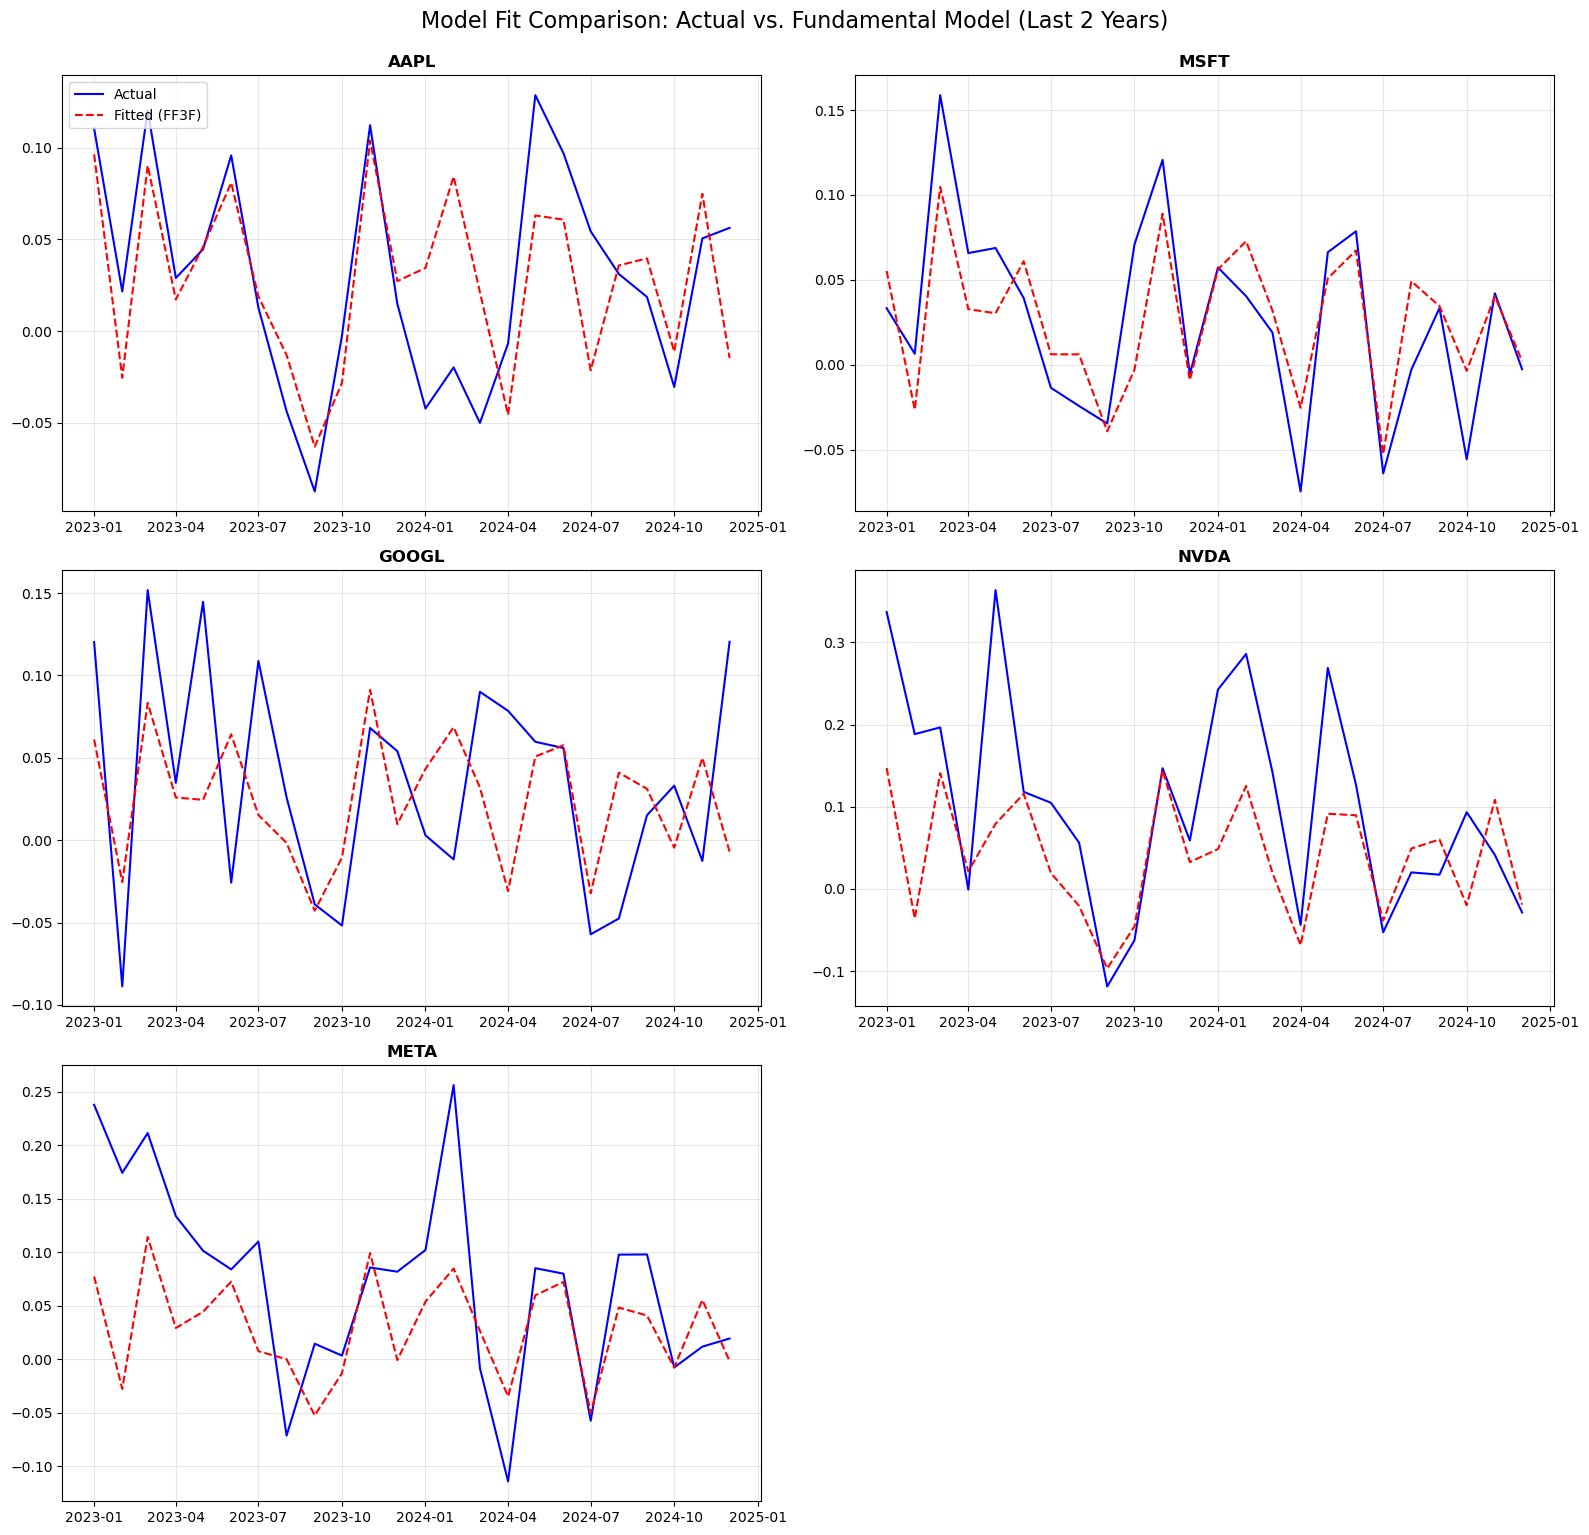

In [122]:
# --- VISUALIZATION 4: THE PANEL GRID (Actual vs. Fitted for ALL) ---
# Just adding all the other observable stocks
# Create a figure with a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten() # Flattens the grid so we can loop through it easily

# We focus on the last 2 years (like your NVDA graph) to see the detail
subset = -24 

for i, ticker in enumerate(tickers):
    ax = axes[i] # Select the specific subplot for this stock
    
    # 1. Re-calculate the specific model for this stock to get its unique Betas
    # (We have to do this because every stock has different betas)
    y_col = f'{ticker}_ex_ret'
    X_ff3f = sm.add_constant(merged_data[['Mkt_RF', 'SMB', 'HML']])
    model = sm.OLS(merged_data[y_col], X_ff3f).fit()
    
    # 2. Calculate Fitted Return
    b_alpha = model.params['const']
    b_mkt = model.params['Mkt_RF']
    b_smb = model.params['SMB']
    b_hml = model.params['HML']
    
    fitted_return = (merged_data['RF'] + 
                     (b_mkt * merged_data['Mkt_RF']) + 
                     (b_smb * merged_data['SMB']) + 
                     (b_hml * merged_data['HML']))
    
    # 3. Plot on the specific subplot (ax)
    # Use 'ticker' as the column name (based on your previous feedback)
    ax.plot(merged_data.index.to_timestamp()[subset:], 
            merged_data[ticker][subset:], 
            label='Actual', color='blue', linewidth=1.5)
            
    ax.plot(merged_data.index.to_timestamp()[subset:], 
            fitted_return[subset:], 
            label='Fitted (FF3F)', color='red', linestyle='--', linewidth=1.5)
    
    # Formatting for each box
    ax.set_title(f'{ticker}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Only put the legend on the first plot to save space
    if i == 0:
        ax.legend(loc='upper left')

# 4. Clean up
# We have 5 stocks but 6 spots in the grid. Hide the empty 6th spot.
if len(tickers) < 6:
    fig.delaxes(axes[5])

plt.tight_layout() # Adjusts spacing so titles don't overlap
plt.suptitle('Model Fit Comparison: Actual vs. Fundamental Model (Last 2 Years)', fontsize=16, y=1.02)
plt.show()

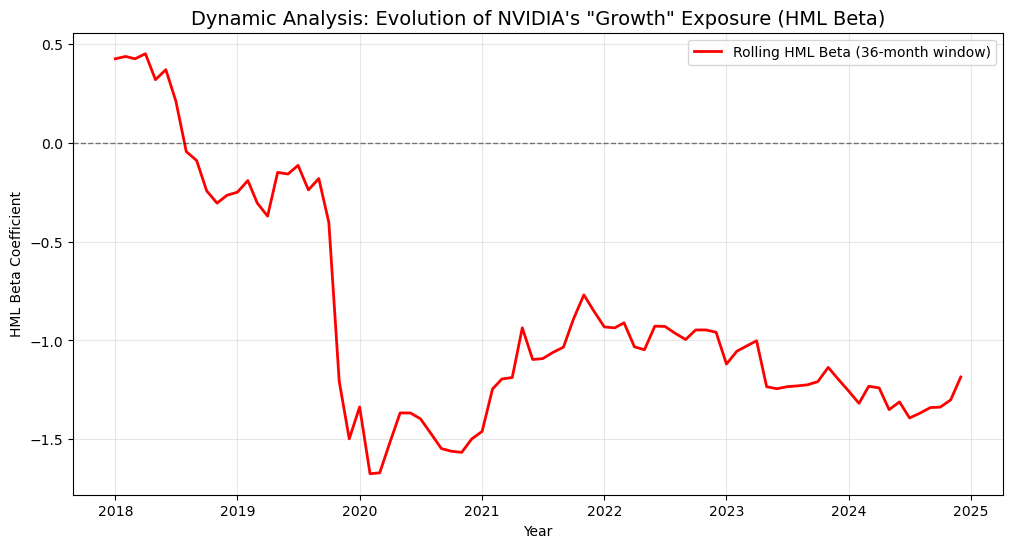

In [113]:
# --- ROLLING BETA ANALYSIS (Dynamic Approach) ---

# We will calculate the HML beta for NVDA over a 36-month rolling window
# This shows how the "Growth" characteristic has evolved over time.
# What we do here is ask ourselved whether NVIDIA always behaved like a growth stock, or did its risk profile change during the AI boom?
# To check: We run a rolling regression (e.g., a 36-month window) to see how the HML beta changes over time.
# If we see that the HML beta became more negative recently we can prove the "dynamic nature" of risk.

from statsmodels.regression.rolling import RollingOLS

# 1. Setup Data for Rolling Regression
y_var = merged_data['NVDA_ex_ret']
X_vars = sm.add_constant(merged_data[['Mkt_RF', 'SMB', 'HML']])

# 2. Run Rolling OLS (Window = 36 months)
rolling_model = RollingOLS(y_var, X_vars, window=36)
rolling_results = rolling_model.fit()

# 3. Get the coefficients
rolling_params = rolling_results.params

# 4. Plot the HML Beta over time
plt.figure(figsize=(12, 6))

# Plot the HML Beta
plt.plot(rolling_params.index.to_timestamp(), 
         rolling_params['HML'], 
         color='red', linewidth=2, label='Rolling HML Beta (36-month window)')

# Add a zero line for reference
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Dynamic Analysis: Evolution of NVIDIA\'s "Growth" Exposure (HML Beta)', fontsize=14)
plt.ylabel('HML Beta Coefficient')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)

# Add interpretation text to the plot (Optional, but helpful)
# plt.text(pd.Timestamp('2020-01-01'), -0.5, 'Negative = Growth Stock', color='purple', fontsize=10)

plt.show()

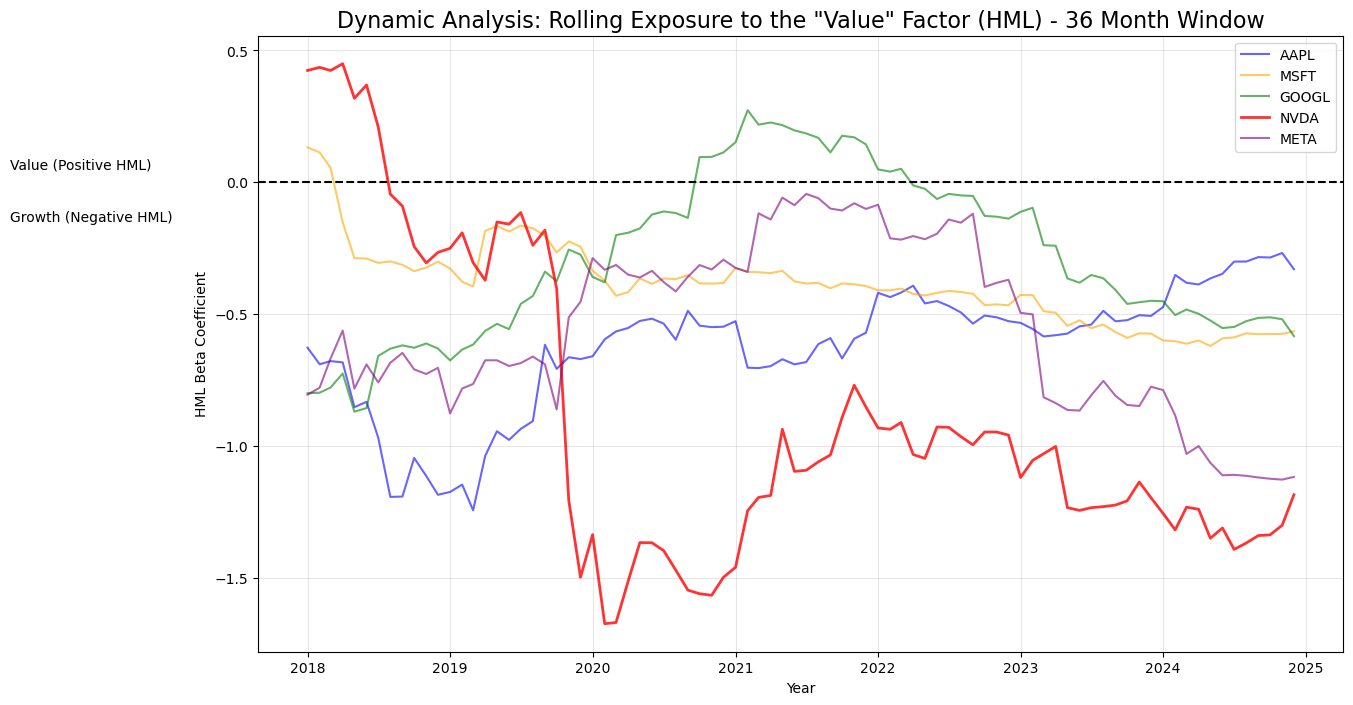

In [115]:
# --- VISUALIZATION: DYNAMIC BETA FOR ALL STOCKS ---
# Here i just expand the dynalic beta to see all the Tech stocks we are observing

plt.figure(figsize=(14, 8))

# Define colors for consistency
colors = {'AAPL': 'blue', 'MSFT': 'orange', 'GOOGL': 'green', 'NVDA': 'red', 'META': 'purple'}

# Loop through each stock
for ticker in tickers:
    # 1. Setup Data
    # Note: We use the same X variables (Market, SMB, HML) for everyone
    y_var = merged_data[f'{ticker}_ex_ret']
    X_vars = sm.add_constant(merged_data[['Mkt_RF', 'SMB', 'HML']])

    # 2. Run Rolling OLS (Window = 36 months)
    rolling_model = RollingOLS(y_var, X_vars, window=36)
    rolling_results = rolling_model.fit()
    rolling_params = rolling_results.params

    # 3. Plot just the HML Beta
    # We make NVDA thicker (linewidth=3) to make it stand out as the "star"
    lw = 2 if ticker == 'NVDA' else 1.5
    alpha = 0.8 if ticker == 'NVDA' else 0.6 # Make others slightly transparent
    
    plt.plot(rolling_params.index.to_timestamp(), 
             rolling_params['HML'], 
             label=ticker, 
             color=colors[ticker], 
             linewidth=lw, 
             alpha=alpha)

# Add a zero line for reference (Value vs Growth boundary)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.text(merged_data.index.to_timestamp()[10], 0.05, 'Value (Positive HML)', fontsize=10)
plt.text(merged_data.index.to_timestamp()[10], -0.15, 'Growth (Negative HML)', fontsize=10)

plt.title('Dynamic Analysis: Rolling Exposure to the "Value" Factor (HML) - 36 Month Window', fontsize=16)
plt.ylabel('HML Beta Coefficient')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

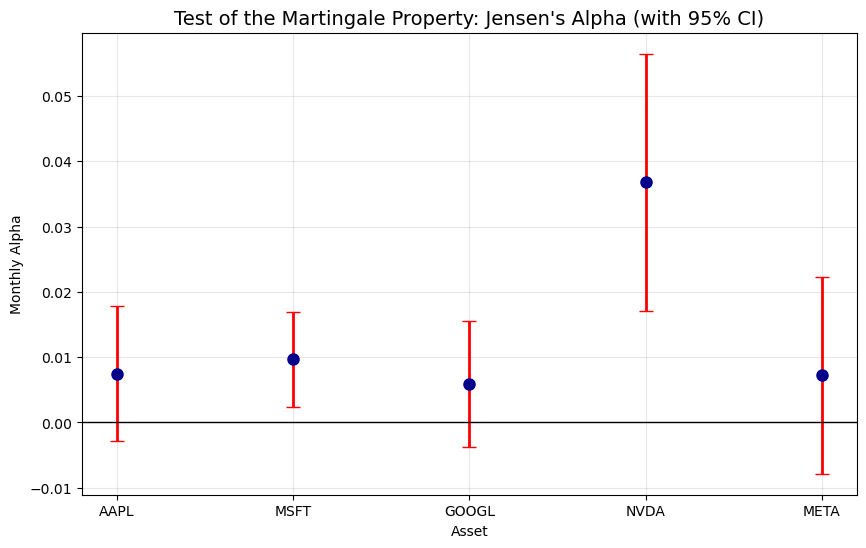

In [117]:
# ---  ALPHA CONFIDENCE INTERVALS ---

# We want to see if the Alpha is statistically different from Zero.
# We will pull the Alpha and its 95% Confidence Interval for all 5 stocks from the FF3F model.
# The Theory: If the Martingale property holds (meaning the market is efficient and your model works), the "Alpha" (the blue dot) should be zero.
# The very high Alpha for NVDIA is a 'missing factor' (like an AI-Hype factor) that our model doesn't have
# For MSFT we see a value slightly above zero indicating "Marginal Outperfomance"

alphas = []
errors = []
tickers_list = []

for ticker in tickers:
    # Re-run the FF3F model quickly to get data
    y = merged_data[f'{ticker}_ex_ret']
    X = sm.add_constant(merged_data[['Mkt_RF', 'SMB', 'HML']])
    model = sm.OLS(y, X).fit()
    
    # Get Alpha (const) and its confidence interval
    alpha = model.params['const']
    conf_int = model.conf_int().loc['const'] # Returns [lower, upper]
    
    # Calculate the error bar size (Distance from Alpha to Upper Bound)
    error = conf_int[1] - alpha
    
    alphas.append(alpha)
    errors.append(error)
    tickers_list.append(ticker)

# Plotting
plt.figure(figsize=(10, 6))

# Create an error bar chart
plt.errorbar(tickers_list, alphas, yerr=errors, fmt='o', color='darkblue', 
             ecolor='red', capsize=5, elinewidth=2, markersize=8)

# Add a zero line (The Martingale Hypothesis)
plt.axhline(0, color='black', linestyle='-', linewidth=1)

plt.title('Test of the Martingale Property: Jensen\'s Alpha (with 95% CI)', fontsize=14)
plt.ylabel('Monthly Alpha')
plt.xlabel('Asset')
plt.grid(True, alpha=0.3)

plt.show()